# 1. Perkenalan Dataset

**Nama:** ASEP HARYANA SAPUTRA  
**Dataset:** Poker Hand - UCI Machine Learning Repository  
**URL Sumber:** [UCI Poker Hand](https://archive.ics.uci.edu/dataset/158/poker+hand)


**Deskripsi Dataset:**
Dataset Poker Hand terdiri dari 1.025.010 instance dengan 10 fitur input dan 1 label kelas. Tantangan utamanya adalah class imbalance ekstrem.

# 2. Import Library

In [37]:
!pip install -r requirements.txt

In [38]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import time
import mlflow
import mlflow.sklearn
import joblib
import shutil
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score
from imblearn.over_sampling import SMOTE
from collections import Counter

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
print('Libraries loaded successfully.')


Libraries loaded successfully.


# 3. Memuat Dataset

In [39]:
# Column definitions berdasarkan poker-hand.names
COLUMNS = [
    'S1', 'C1',  # Suit & Rank card 1
    'S2', 'C2',  # Suit & Rank card 2
    'S3', 'C3',  # Suit & Rank card 3
    'S4', 'C4',  # Suit & Rank card 4
    'S5', 'C5',  # Suit & Rank card 5
    'CLASS'      # Target: Poker Hand (0-9)
]

CLASS_NAMES = {
    0: 'Nothing',
    1: 'One Pair',
    2: 'Two Pairs',
    3: 'Three of a Kind',
    4: 'Straight',
    5: 'Flush',
    6: 'Full House',
    7: 'Four of a Kind',
    8: 'Straight Flush',
    9: 'Royal Flush'
}

RAW_DIR = './pokerhand_raw'

# Load training set
df_train = pd.read_csv(
    os.path.join(RAW_DIR, 'poker-hand-training-true.data'),
    header=None,
    names=COLUMNS
)

# Sample 100k rows dari testing set untuk validasi EDA (full set = 1M rows)
df_test_sample = pd.read_csv(
    os.path.join(RAW_DIR, 'poker-hand-testing.data'),
    header=None,
    names=COLUMNS,
    nrows=100_000
)

print(f'Training shape: {df_train.shape}')
print(f'Test sample shape: {df_test_sample.shape}')

Training shape: (25010, 11)
Test sample shape: (100000, 11)


# 4. Exploratory Data Analysis (EDA)

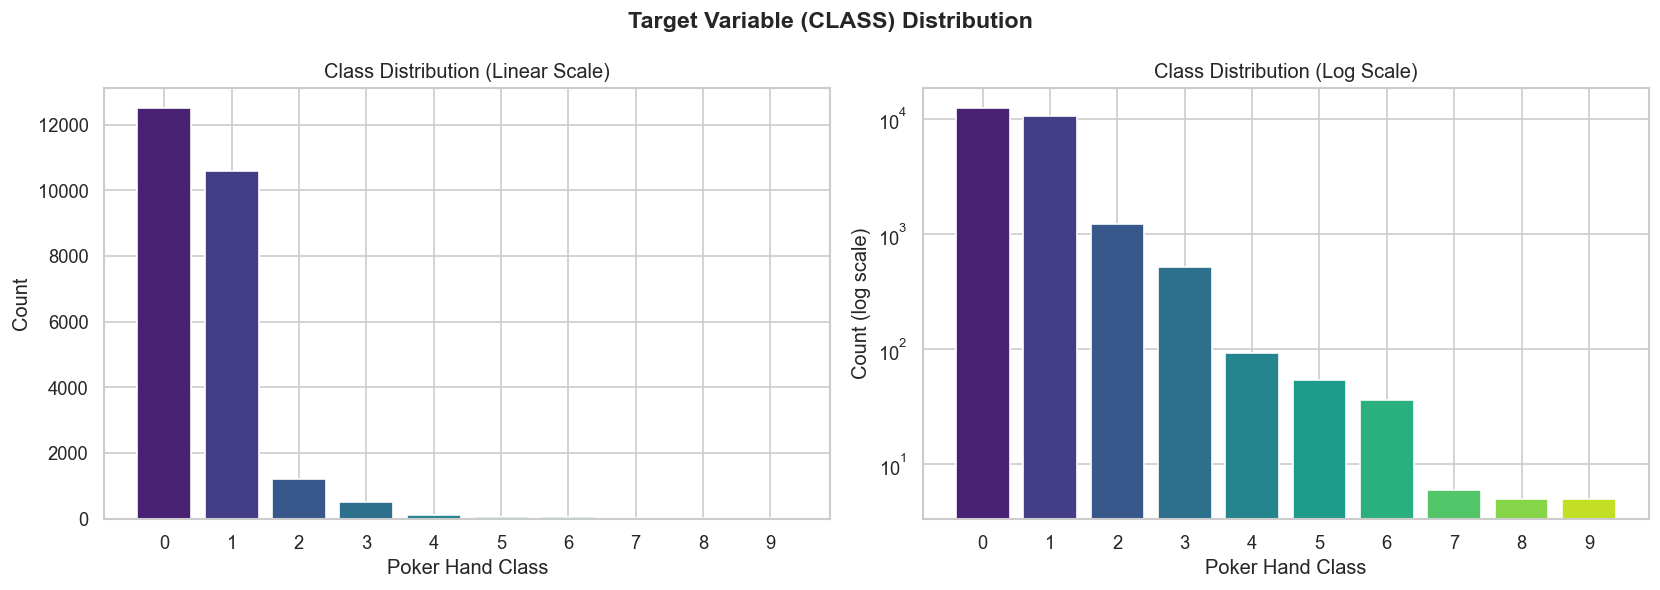


Class counts:
  Class 0 (Nothing): 12493 (49.95%)
  Class 1 (One Pair): 10599 (42.38%)
  Class 2 (Two Pairs): 1206 (4.82%)
  Class 3 (Three of a Kind): 513 (2.05%)
  Class 4 (Straight): 93 (0.37%)
  Class 5 (Flush): 54 (0.22%)
  Class 6 (Full House): 36 (0.14%)
  Class 7 (Four of a Kind): 6 (0.02%)
  Class 8 (Straight Flush): 5 (0.02%)
  Class 9 (Royal Flush): 5 (0.02%)


In [40]:
# ============================
# 3.1 Class Distribution
# ============================
class_counts = df_train['CLASS'].value_counts().sort_index()
class_labels = [f'{k}: {CLASS_NAMES[k]}' for k in class_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale
axes[0].bar(class_counts.index, class_counts.values, color=sns.color_palette('viridis', 10))
axes[0].set_xlabel('Poker Hand Class')
axes[0].set_ylabel('Count')
axes[0].set_title('Class Distribution (Linear Scale)')
axes[0].set_xticks(range(10))

# Log scale — reveals rare classes
axes[1].bar(class_counts.index, class_counts.values, color=sns.color_palette('viridis', 10))
axes[1].set_yscale('log')
axes[1].set_xlabel('Poker Hand Class')
axes[1].set_ylabel('Count (log scale)')
axes[1].set_title('Class Distribution (Log Scale)')
axes[1].set_xticks(range(10))

plt.suptitle('Target Variable (CLASS) Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nClass counts:')
for k, v in class_counts.items():
    print(f'  Class {k} ({CLASS_NAMES[k]}): {v} ({v/len(df_train)*100:.2f}%)')

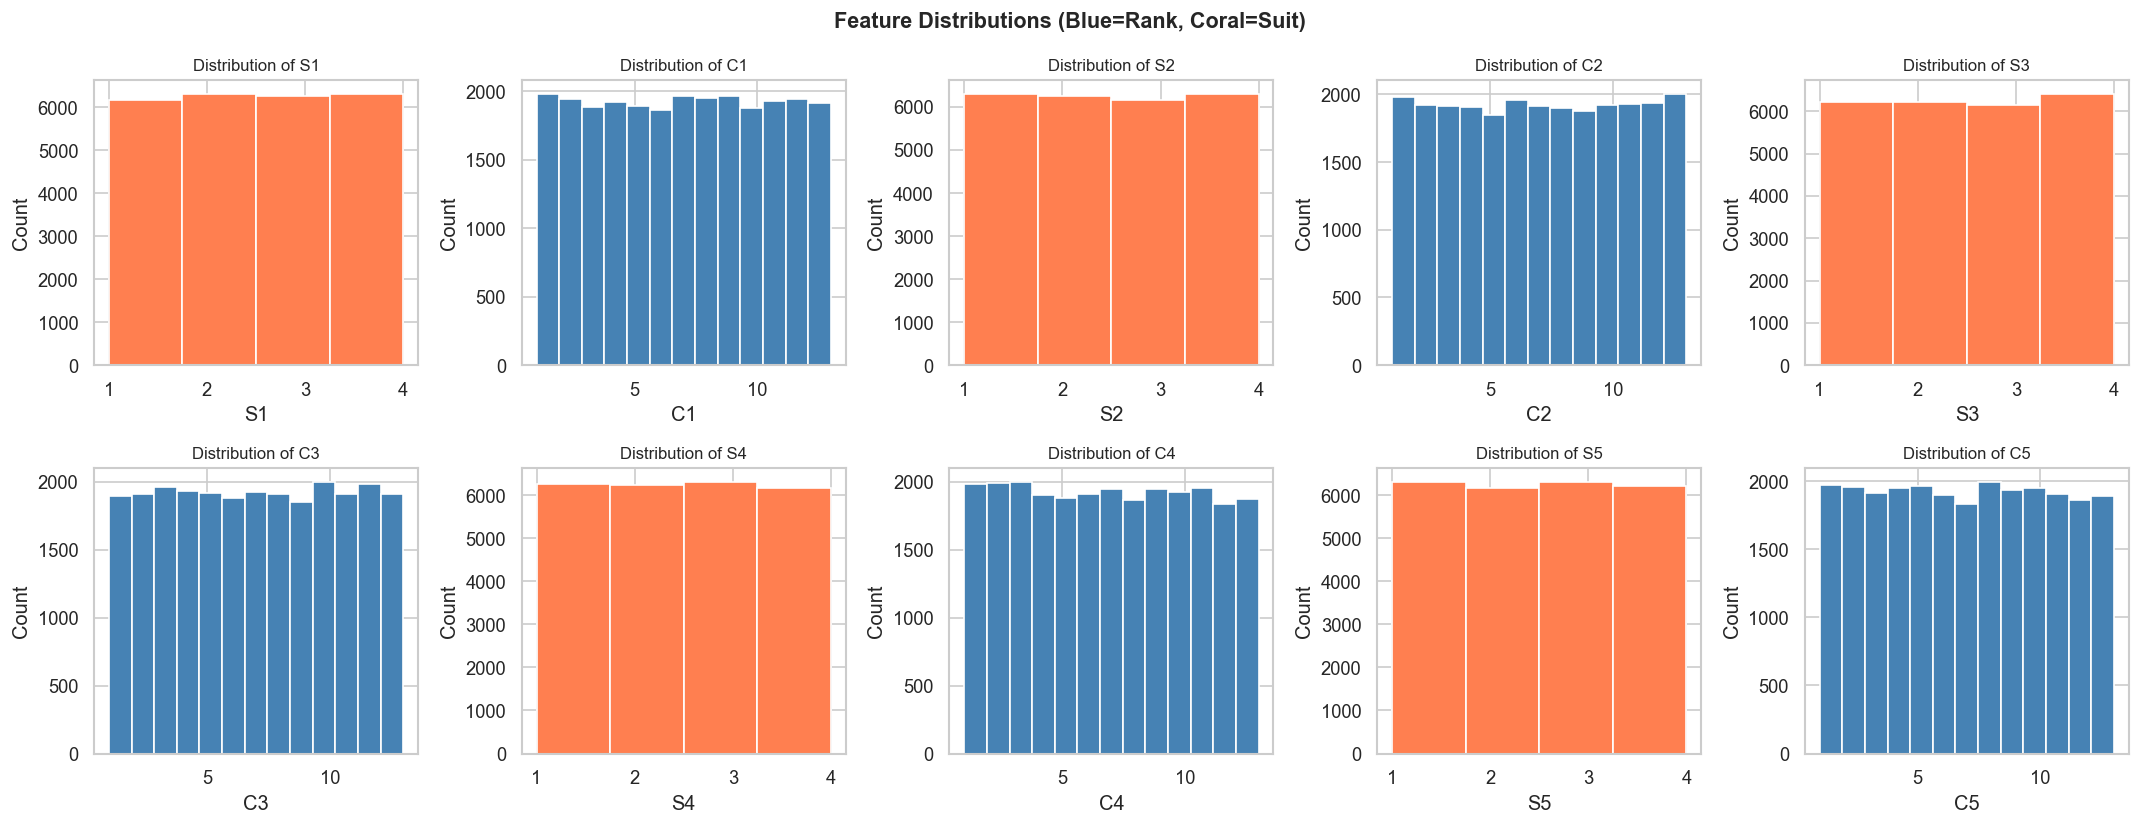

In [41]:
# ============================
# 3.2 Distribusi Fitur Numerik
# ============================
feature_cols = [c for c in COLUMNS if c != 'CLASS']
suit_cols = ['S1', 'S2', 'S3', 'S4', 'S5']
rank_cols = ['C1', 'C2', 'C3', 'C4', 'C5']

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].hist(df_train[col], bins=df_train[col].nunique(), edgecolor='white', 
                 color='steelblue' if col.startswith('C') else 'coral')
    axes[i].set_title(f'Distribution of {col}', fontsize=10)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.suptitle('Feature Distributions (Blue=Rank, Coral=Suit)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

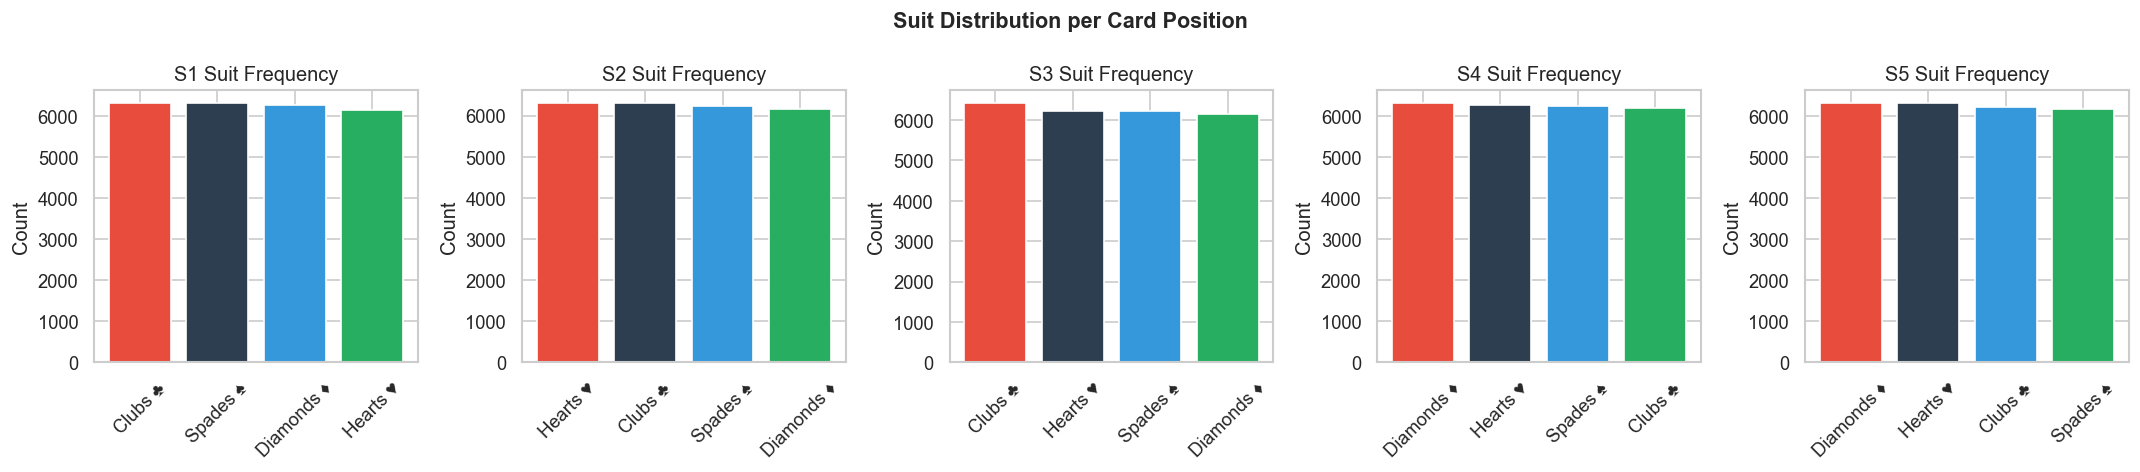

In [42]:
# ============================
# 3.3 Analisis Fitur Kategorikal (Suit)
# Suit values: 1=Hearts, 2=Spades, 3=Diamonds, 4=Clubs
# ============================
suit_map = {1: 'Hearts ♥', 2: 'Spades ♠', 3: 'Diamonds ♦', 4: 'Clubs ♣'}

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for i, col in enumerate(suit_cols):
    counts = df_train[col].map(suit_map).value_counts()
    axes[i].bar(counts.index, counts.values, color=['#e74c3c', '#2c3e50', '#3498db', '#27ae60'])
    axes[i].set_title(f'{col} Suit Frequency')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylabel('Count')

plt.suptitle('Suit Distribution per Card Position', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

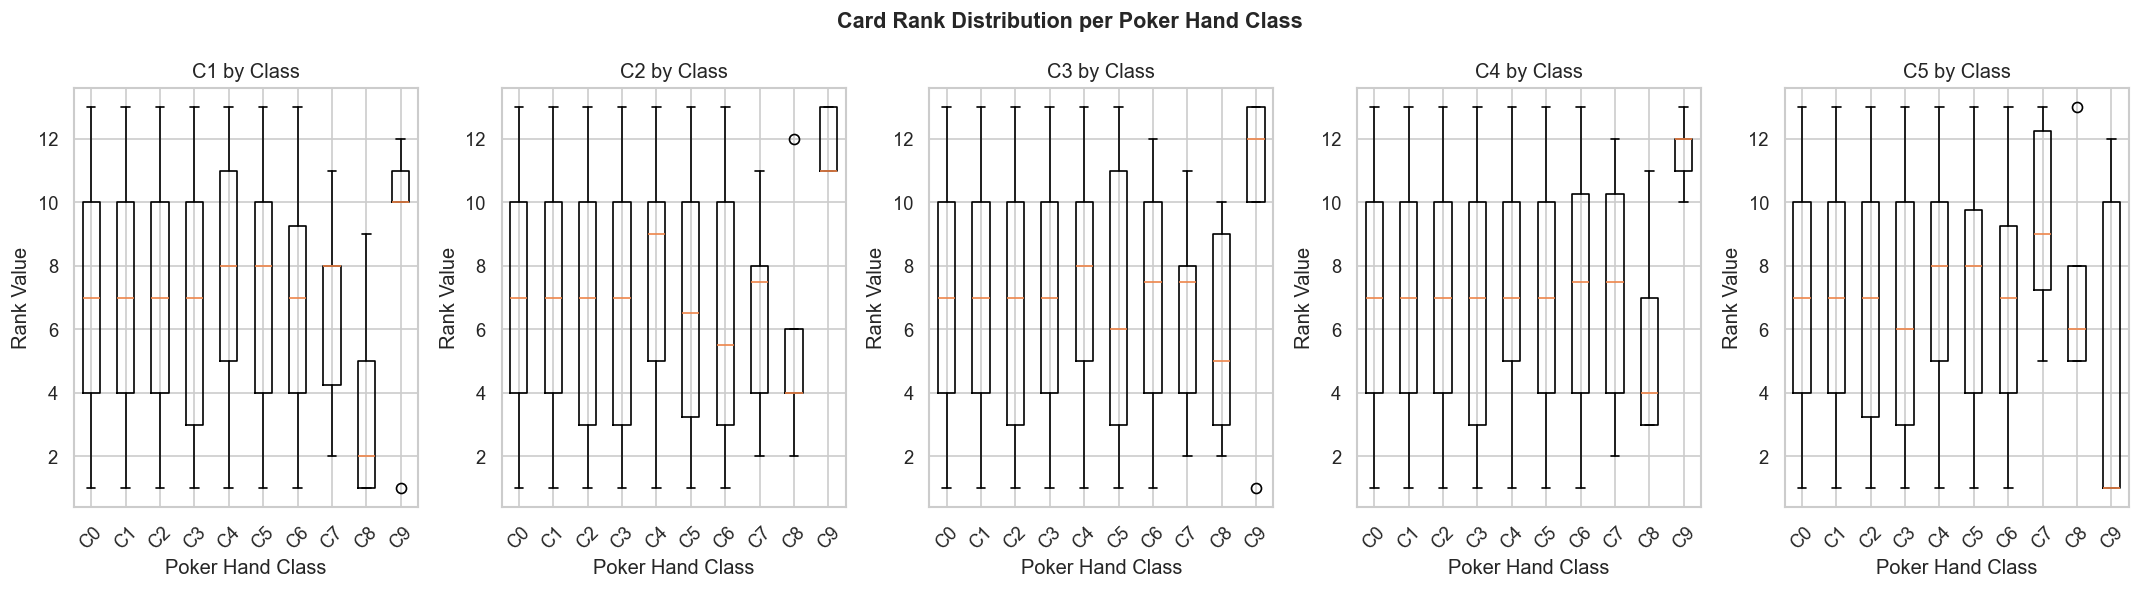

In [43]:
# ============================
# 3.5 Boxplot Rank per Class
# ============================
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for i, col in enumerate(rank_cols):
    # Sample untuk kecepatan plotting
    sample = df_train.sample(min(5000, len(df_train)), random_state=42)
    class_order = sorted(df_train['CLASS'].unique())
    sample['CLASS_NAME'] = sample['CLASS'].map(lambda x: f'C{x}')
    axes[i].boxplot(
        [df_train.loc[df_train['CLASS'] == c, col].values for c in class_order],
        labels=[f'C{c}' for c in class_order]
    )
    axes[i].set_title(f'{col} by Class')
    axes[i].set_xlabel('Poker Hand Class')
    axes[i].set_ylabel('Rank Value')
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Card Rank Distribution per Poker Hand Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 5. Data Preprocessing

## 5.1 Menghapus atau Menangani Data Kosong (Missing Values)

In [44]:
# ============================
# Cek Missing Values
# ============================
missing = df_train.isnull().sum()
print('Missing values per column:')
print(missing)
print(f'\nTotal missing: {missing.sum()}')

Missing values per column:
S1       0
C1       0
S2       0
C2       0
S3       0
C3       0
S4       0
C4       0
S5       0
C5       0
CLASS    0
dtype: int64

Total missing: 0


In [45]:
# ============================
# 4.1 Handle Missing Values
# ============================
# Berdasarkan EDA: dataset ini TIDAK memiliki missing values.
# Namun kita tetap validasi dan log.
assert df_train.isnull().sum().sum() == 0, 'Unexpected missing values found!'
print('✅ No missing values — no imputation needed.')

✅ No missing values — no imputation needed.


## 5.2 Menghapus Data Duplikat

In [46]:
# 1. Feature Engineering (Derived Features)
print("Adding derived features...")
df_feat = df_train.copy()
SUIT_COLS = ['S1', 'S2', 'S3', 'S4', 'S5']
RANK_COLS = ['C1', 'C2', 'C3', 'C4', 'C5']
DERIVED_COLS = ['all_same_suit', 'n_unique_suits', 'n_unique_ranks', 'rank_range']

df_feat['all_same_suit'] = (df_feat[SUIT_COLS].nunique(axis=1) == 1).astype(int)
df_feat['n_unique_suits'] = df_feat[SUIT_COLS].nunique(axis=1)
df_feat['n_unique_ranks'] = df_feat[RANK_COLS].nunique(axis=1)
df_feat['rank_range'] = df_feat[RANK_COLS].max(axis=1) - df_feat[RANK_COLS].min(axis=1)

X = df_feat.drop(columns=['CLASS'])
y = df_feat['CLASS']

# 2. Train-Test Split (80/20 Stratified)
print("Splitting data (80/20)...")
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


Adding derived features...
Splitting data (80/20)...


In [47]:
# ============================
# Duplicate Removal
# ============================
print(f'Rows before duplicate removal: {len(df_train)}')
n_dup = df_train.duplicated().sum()
print(f'Found {n_dup} duplicate rows.')

df_train = df_train.drop_duplicates()
print(f'Rows after duplicate removal: {len(df_train)}')
print('Duplicate removal step complete.')

Rows before duplicate removal: 25010
Found 2 duplicate rows.
Rows after duplicate removal: 25008
Duplicate removal step complete.


## 5.3 Normalisasi atau Standarisasi Fitur

In [48]:
print("Defining StandarScaler (Normalisasi)...")
rank_scale = StandardScaler()


Defining StandarScaler (Normalisasi)...


*Menggunakan StandardScaler untuk penskalaan fitur numerik.*

## 5.4 Deteksi dan Penanganan Outlier

In [49]:
print("Dataset is completely constrained by poker rules (1-4 suit, 1-13 rank).")
print("Outliers are systematically impossible, proceeding.")


Dataset is completely constrained by poker rules (1-4 suit, 1-13 rank).
Outliers are systematically impossible, proceeding.


*Dilakukan pengecekan rentang nilai statis sesuai aturan permainan poker.*

## 5.5 Encoding Data Kategorikal

In [50]:
print("Encoding and Scaling pipeline...")
preprocessor = ColumnTransformer(
    transformers=[
        ('suit_ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), SUIT_COLS),
        ('rank_scale', rank_scale, RANK_COLS + DERIVED_COLS)
    ],
    remainder='drop'
)

X_train_enc = preprocessor.fit_transform(X_train_raw)
X_test_enc = preprocessor.transform(X_test_raw)

ohe_names = preprocessor.named_transformers_['suit_ohe'].get_feature_names_out(SUIT_COLS).tolist()
scale_names = RANK_COLS + DERIVED_COLS
feature_names = ohe_names + scale_names

print(f'Preprocessed features count: {len(feature_names)}')
print(f'Feature list: {feature_names}')

Encoding and Scaling pipeline...
Preprocessed features count: 29
Feature list: ['S1_1', 'S1_2', 'S1_3', 'S1_4', 'S2_1', 'S2_2', 'S2_3', 'S2_4', 'S3_1', 'S3_2', 'S3_3', 'S3_4', 'S4_1', 'S4_2', 'S4_3', 'S4_4', 'S5_1', 'S5_2', 'S5_3', 'S5_4', 'C1', 'C2', 'C3', 'C4', 'C5', 'all_same_suit', 'n_unique_suits', 'n_unique_ranks', 'rank_range']


*Encoding One-Hot diterapkan pada fitur Suit.*

## 5.6 Binning (Pengelompokan Data)

In [51]:
print("Binning (Pengelompokan Data) is skipped for Poker rules.")


Binning (Pengelompokan Data) is skipped for Poker rules.


Applying SMOTE oversampling to training data...
Original Class Distribution: Counter({0: 9994, 1: 8479, 2: 965, 3: 411, 4: 74, 5: 43, 6: 29, 7: 5, 9: 4, 8: 4})
Balanced Class Distribution: Counter({0: 9994, 2: 9994, 3: 9994, 1: 9994, 9: 9994, 5: 9994, 6: 9994, 4: 9994, 8: 9994, 7: 9994})
SUCCESS: CSV files for X_train, X_test, y_train, y_test saved to: ./Membangun_model/pokerhand_preprocessing
SUCCESS: Preprocessor saved to: ./Membangun_model/pokerhand_preprocessing/preprocessor.joblib


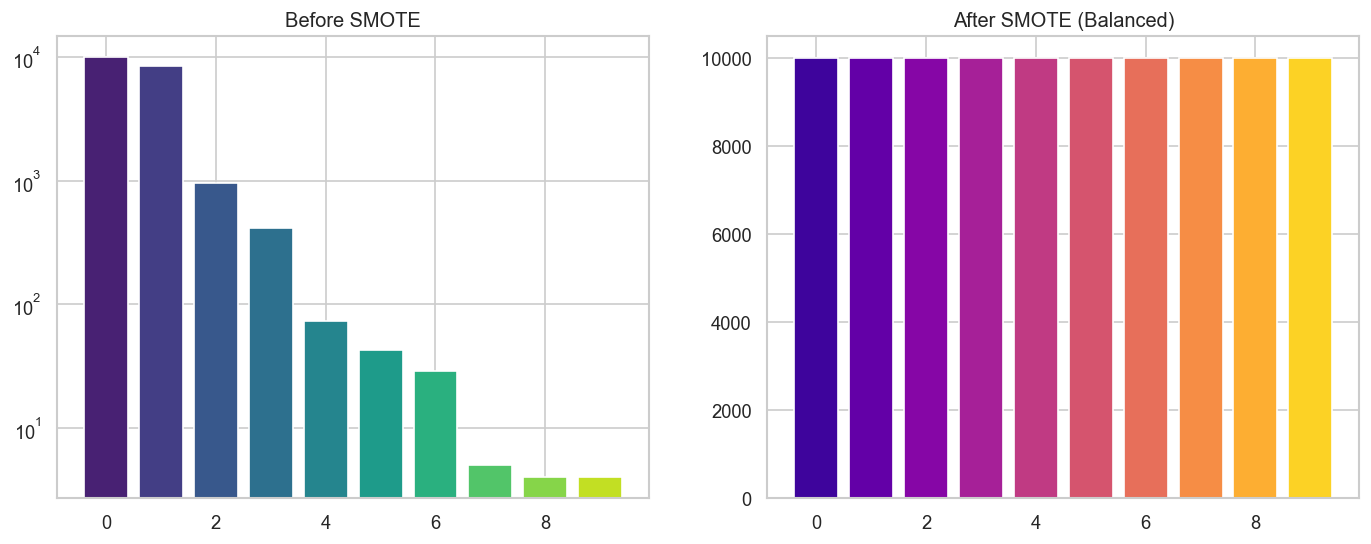

In [52]:
print('Applying SMOTE oversampling to training data...')
smote = SMOTE(random_state=42, k_neighbors=3)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_enc, y_train)
print(f'Original Class Distribution: {Counter(y_train)}')
print(f'Balanced Class Distribution: {Counter(y_train_balanced)}')

# 5. Saving Preprocessed Data
out_dir = './Membangun_model/pokerhand_preprocessing'
os.makedirs(out_dir, exist_ok=True)

pd.DataFrame(X_train_balanced, columns=feature_names).to_csv(os.path.join(out_dir, 'X_train.csv'), index=False)
pd.DataFrame(X_test_enc, columns=feature_names).to_csv(os.path.join(out_dir, 'X_test.csv'), index=False)
pd.DataFrame({'CLASS': y_train_balanced}).to_csv(os.path.join(out_dir, 'y_train.csv'), index=False)
pd.DataFrame({'CLASS': y_test}).to_csv(os.path.join(out_dir, 'y_test.csv'), index=False)
joblib.dump(preprocessor, os.path.join(out_dir, 'preprocessor.joblib'))
print(f'SUCCESS: CSV files for X_train, X_test, y_train, y_test saved to: {out_dir}')
print(f'SUCCESS: Preprocessor saved to: {os.path.join(out_dir, "preprocessor.joblib")}')

before = Counter(y_train)
after  = Counter(y_train_balanced)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
classes = sorted(before.keys())
axes[0].bar(classes, [before[c] for c in classes], color=sns.color_palette('viridis', 10))
axes[0].set_title('Before SMOTE')
axes[0].set_yscale('log')

axes[1].bar(classes, [after[c] for c in classes], color=sns.color_palette('plasma', 10))
axes[1].set_title('After SMOTE (Balanced)')
plt.show()


*Binning tidak diperlukan untuk dataset ini karena semua fitur bersifat diskrit atau ordinal.*

# 6. Modelling

In [53]:
import mlflow
import mlflow.sklearn
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
import time

mlflow.sklearn.autolog(disable=True)
mlflow.set_tracking_uri('./Membangun_model/mlruns')
mlflow.set_experiment('poker-hand-tuning-local')

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 15],
    'min_samples_split': [2, 5],
}

base_model = RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

t0 = time.time()
grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    cv=cv,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=1,
    refit=True,
    return_train_score=True
)
print("Fitting GridSearchCV...")
grid_search.fit(X_train_balanced, y_train_balanced)

best_params = grid_search.best_params_
best_model = grid_search.best_estimator_
print(f"Best params : {best_params}")


Fitting GridSearchCV...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best params : {'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 200}


# 7. Evaluasi

2026/03/02 13:49:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/02 13:49:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


              precision    recall  f1-score   support

           0     0.9988    1.0000    0.9994      2499
           1     1.0000    1.0000    1.0000      2120
           2     0.7074    0.9129    0.7971       241
           3     0.3636    0.1176    0.1778       102
           4     1.0000    0.8421    0.9143        19
           5     0.8333    0.9091    0.8696        11
           6     0.8571    0.8571    0.8571         7
           7     0.0000    0.0000    0.0000         1
           8     0.0000    0.0000    0.0000         1
           9     0.0000    0.0000    0.0000         1

    accuracy                         0.9762      5002
   macro avg     0.5760    0.5639    0.5615      5002
weighted avg     0.9712    0.9762    0.9717      5002



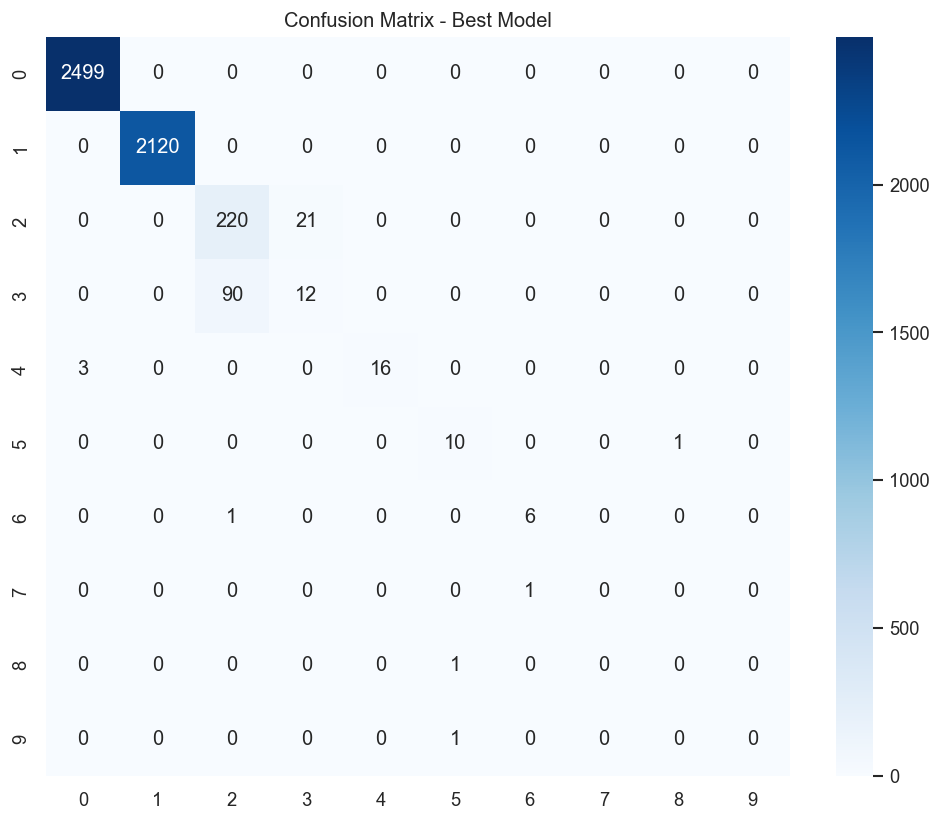

2026/03/02 13:49:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [54]:
with mlflow.start_run(run_name='RandomForest_GridSearchCV') as run:
    for k, v in best_params.items():
        mlflow.log_param(f'best_{k}', v)
        
    y_pred = best_model.predict(X_test_enc)
    acc = accuracy_score(y_test, y_pred)
    f1_w = f1_score(y_test, y_pred, average='weighted')
    
    mlflow.log_metric('accuracy', acc)
    mlflow.log_metric('f1_weighted', f1_w)
    mlflow.sklearn.log_model(sk_model=best_model, artifact_path='best_model')
    
    report = classification_report(y_test, y_pred, digits=4)
    print(report)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix - Best Model')
    plt.show()
    
    local_export = './best_model_local'
    if os.path.exists(local_export): shutil.rmtree(local_export)
    mlflow.sklearn.save_model(sk_model=best_model, path=local_export)
